In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from model.mlp import MLPBinary
from model.train import train

MODEL_DATA = "../data/gold/final_imdb.csv"
RESULTS = "../results/"

df = pd.read_csv(MODEL_DATA)

FEATURES = [
    "neg","neu","pos","compound","tb_polarity","tb_subjectivity"
]

X = df[FEATURES].to_numpy(dtype=np.float32) # we convert to numerical vals

Y = (df["sentiment"] == "positive").astype(np.float32).to_numpy().reshape(-1,1) # assign target to be sentiment

# split data 70% train, 15% test + 15% validation

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size= 0.3, random_state= 0 , stratify= Y
)


X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=0 , stratify=Y_temp
)

In [2]:
model = MLPBinary(d_in=X_train.shape[1], n_neurons=16, learning_rate=0.01, seed=0) # we set number of features, neurons, and learning rate
train_model = train(model, X_train, Y_train, X_val, Y_val, epochs=50, batch_size=64)


epoch 001 | train_loss=0.5958 | val_loss=0.5928 | val_acc=0.7077
epoch 002 | train_loss=0.5702 | val_loss=0.5675 | val_acc=0.7143
epoch 003 | train_loss=0.5554 | val_loss=0.5532 | val_acc=0.7169
epoch 004 | train_loss=0.5429 | val_loss=0.5414 | val_acc=0.7229
epoch 005 | train_loss=0.5318 | val_loss=0.5307 | val_acc=0.7265
epoch 006 | train_loss=0.5219 | val_loss=0.5214 | val_acc=0.7343
epoch 007 | train_loss=0.5131 | val_loss=0.5130 | val_acc=0.7373
epoch 008 | train_loss=0.5057 | val_loss=0.5060 | val_acc=0.7447
epoch 009 | train_loss=0.4994 | val_loss=0.5002 | val_acc=0.7512
epoch 010 | train_loss=0.4943 | val_loss=0.4953 | val_acc=0.7548
epoch 011 | train_loss=0.4903 | val_loss=0.4915 | val_acc=0.7585
epoch 012 | train_loss=0.4869 | val_loss=0.4885 | val_acc=0.7623
epoch 013 | train_loss=0.4848 | val_loss=0.4870 | val_acc=0.7661
epoch 014 | train_loss=0.4823 | val_loss=0.4845 | val_acc=0.7667
epoch 015 | train_loss=0.4805 | val_loss=0.4828 | val_acc=0.7687
epoch 016 | train_loss=0.

In [3]:
test_pred = model.predict(X_test, threshold=0.5) # testing the model
test_acc = float((test_pred == Y_test).mean()) # comparing with the ground_truth
print("test_acc:", round(test_acc, 3))


test_acc: 0.785


In [4]:
tp = ((Y_test == 1) & (test_pred == 1)).sum()
fp = ((Y_test == 1) & (test_pred == 0)).sum()
precision = tp / (tp + fp + 1e-12)
print("precision:", round(float(precision), 3))


precision: 0.788


In [5]:
fn = ((Y_test == 0) & (test_pred == 1)).sum()
recall = tp / (tp + fn + 1e-12)
print("recall:", round(float(recall), 3))

recall: 0.783


In [6]:
f1 = 2 * precision * recall / (precision + recall + 1e-12)
print("f1:", round(float(f1), 3))


f1: 0.786


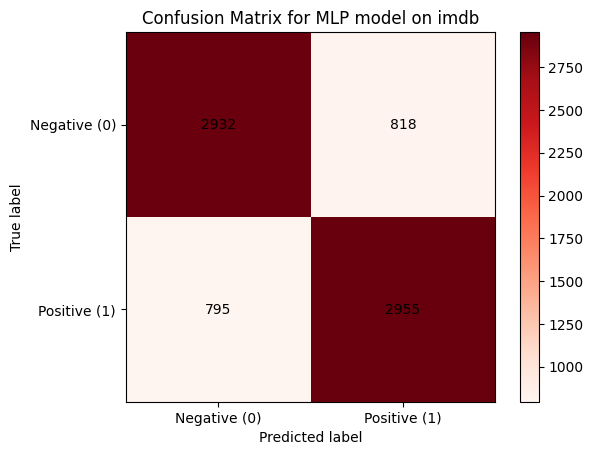

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# creating the confusion matrix
CM_PATH="../results/confusion_matrix.png"


confusion= confusion_matrix(Y_test.astype(int).ravel(), test_pred.astype(int).ravel())

plt.figure()
plt.imshow(confusion, cmap="Reds")
plt.title("Confusion Matrix for MLP model on imdb")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.yticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.colorbar()

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, str(confusion[i, j]), ha="center", va="center")

plt.savefig(CM_PATH, dpi=250, bbox_inches="tight" )
plt.show()

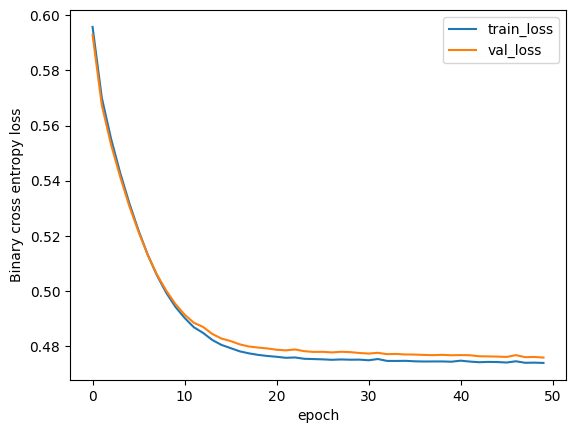

In [ ]:
import matplotlib.pyplot as plt

LOSS_PATH="../results/loss_curve.png"

plt.plot(train_model["train_loss"], label="train_loss")
plt.plot(train_model["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("Binary cross entropy loss")
plt.savefig(LOSS_PATH, dpi=250, bbox_inches="tight")
plt.show()


In [9]:
import pickle
from pathlib import Path

Path("model").mkdir(parents=True, exist_ok=True)

with open("../model/best_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [ ]:
from model.rnn    import RNNBinary
from model.cnn1d  import CNN1DBinary
from model.train  import save_results
from model.preprocessing import build_vocab, encode_and_pad

In [16]:
from model.mlpv2 import MLPBinaryV2

mlp2 = MLPBinaryV2(d_in=X_train.shape[1], n_neurons=16,
                learning_rate=0.01, momentum=0.9)

train_mlp2 = train(mlp2, X_train, Y_train, X_val, Y_val, epochs=50)

save_results(train_mlp2, "mlp_v2", Y_val,
            mlp2.predict(X_val), base_path="../results")

epoch 001 | train_loss=0.4969 | val_loss=0.4982 | val_acc=0.7584
epoch 002 | train_loss=0.4774 | val_loss=0.4799 | val_acc=0.7697
epoch 003 | train_loss=0.4751 | val_loss=0.4776 | val_acc=0.7695
epoch 004 | train_loss=0.4814 | val_loss=0.4841 | val_acc=0.7673
epoch 005 | train_loss=0.4761 | val_loss=0.4776 | val_acc=0.7700
epoch 006 | train_loss=0.4760 | val_loss=0.4774 | val_acc=0.7705
epoch 007 | train_loss=0.4735 | val_loss=0.4752 | val_acc=0.7689
epoch 008 | train_loss=0.4734 | val_loss=0.4751 | val_acc=0.7699
epoch 009 | train_loss=0.4762 | val_loss=0.4780 | val_acc=0.7697
epoch 010 | train_loss=0.4749 | val_loss=0.4761 | val_acc=0.7732
epoch 011 | train_loss=0.4728 | val_loss=0.4743 | val_acc=0.7704
epoch 012 | train_loss=0.4734 | val_loss=0.4750 | val_acc=0.7716
epoch 013 | train_loss=0.4750 | val_loss=0.4766 | val_acc=0.7709
epoch 014 | train_loss=0.4739 | val_loss=0.4757 | val_acc=0.7707
epoch 015 | train_loss=0.4734 | val_loss=0.4752 | val_acc=0.7691
epoch 016 | train_loss=0.

In [17]:
df = pd.read_csv("../data/gold/final_imdb.csv")

from sklearn.model_selection import train_test_split

texts = df["review"].tolist()
t_texts, temp_texts = train_test_split(texts, test_size=0.3, random_state=0, stratify=Y)
val_texts, test_texts = train_test_split(temp_texts, test_size=0.5, random_state=0)

vocab       = build_vocab(t_texts, max_words=10000)
X_train_seq = encode_and_pad(t_texts,    vocab, max_len=200)
X_val_seq   = encode_and_pad(val_texts,  vocab, max_len=200)
X_test_seq  = encode_and_pad(test_texts, vocab, max_len=200)

print(f"Vocab size : {len(vocab)}")
print(f"Train shape: {X_train_seq.shape}")
print(f"Val shape  : {X_val_seq.shape}")

Vocab size : 10000
Train shape: (35000, 200)
Val shape  : (7500, 200)


In [18]:
rnn = RNNBinary(vocab_size=len(vocab)+1, embed_dim=32, hidden_dim=64, learning_rate=0.01)

train_rnn = train(rnn, X_train_seq, Y_train, X_val_seq, Y_val,
                epochs=20, batch_size=64)

save_results(train_rnn, "rnn", Y_val, rnn.predict(X_val_seq), base_path="../results")

epoch 001 | train_loss=0.6931 | val_loss=0.6932 | val_acc=0.5047
epoch 002 | train_loss=0.6946 | val_loss=0.6948 | val_acc=0.5000
epoch 003 | train_loss=0.6931 | val_loss=0.6934 | val_acc=0.5005
epoch 004 | train_loss=0.6929 | val_loss=0.6932 | val_acc=0.4937
epoch 005 | train_loss=0.6936 | val_loss=0.6934 | val_acc=0.5033
epoch 006 | train_loss=0.6930 | val_loss=0.6934 | val_acc=0.4947
epoch 007 | train_loss=0.6929 | val_loss=0.6934 | val_acc=0.5019
epoch 008 | train_loss=0.6927 | val_loss=0.6933 | val_acc=0.4976
epoch 009 | train_loss=0.6953 | val_loss=0.6957 | val_acc=0.4996
epoch 010 | train_loss=0.6929 | val_loss=0.6933 | val_acc=0.4981
epoch 011 | train_loss=0.6930 | val_loss=0.6935 | val_acc=0.4987
epoch 012 | train_loss=0.6931 | val_loss=0.6935 | val_acc=0.5015
epoch 013 | train_loss=0.6933 | val_loss=0.6935 | val_acc=0.4993
epoch 014 | train_loss=0.6928 | val_loss=0.6931 | val_acc=0.4988
epoch 015 | train_loss=0.6935 | val_loss=0.6939 | val_acc=0.5000
epoch 016 | train_loss=0.

In [19]:
cnn = CNN1DBinary(vocab_size=len(vocab)+1, embed_dim=32, n_filters=64, kernel_size=3, learning_rate=0.01)

train_cnn = train(cnn, X_train_seq, Y_train, X_val_seq, Y_val, epochs=20, batch_size=64)

save_results(train_cnn, "cnn1d", Y_val, cnn.predict(X_val_seq), base_path="../results")

epoch 001 | train_loss=0.6923 | val_loss=0.6932 | val_acc=0.4937
epoch 002 | train_loss=0.6901 | val_loss=0.6933 | val_acc=0.4927
epoch 003 | train_loss=0.6857 | val_loss=0.6938 | val_acc=0.4924
epoch 004 | train_loss=0.6794 | val_loss=0.6952 | val_acc=0.4925
epoch 005 | train_loss=0.6716 | val_loss=0.6985 | val_acc=0.4941
epoch 006 | train_loss=0.6637 | val_loss=0.7045 | val_acc=0.4957
epoch 007 | train_loss=0.6559 | val_loss=0.7118 | val_acc=0.4969
epoch 008 | train_loss=0.6478 | val_loss=0.7193 | val_acc=0.4980
epoch 009 | train_loss=0.6386 | val_loss=0.7264 | val_acc=0.4989
epoch 010 | train_loss=0.6291 | val_loss=0.7341 | val_acc=0.4999
epoch 011 | train_loss=0.6200 | val_loss=0.7417 | val_acc=0.5008
epoch 012 | train_loss=0.6102 | val_loss=0.7517 | val_acc=0.4981
epoch 013 | train_loss=0.6023 | val_loss=0.7622 | val_acc=0.4988
epoch 014 | train_loss=0.5958 | val_loss=0.7726 | val_acc=0.4980
epoch 015 | train_loss=0.5908 | val_loss=0.7814 | val_acc=0.5003
epoch 016 | train_loss=0.

In [20]:
results = {
    "MLP v1 (A1)"  : max(train_model["val_acc"]),
    "MLP v2"       : max(train_mlp2["val_acc"]),
    "RNN"          : max(train_rnn["val_acc"]),
    "1D CNN"       : max(train_cnn["val_acc"]),
}

print(f"{'Model':<20} {'Best Val Acc':>12}")
print("-" * 34)
for name, acc in results.items():
    print(f"{name:<20} {acc:>12.4f}")

Model                Best Val Acc
----------------------------------
MLP v1 (A1)                0.7715
MLP v2                     0.7769
RNN                        0.5047
1D CNN                     0.5055
